In [1]:
import numpy as np
import pandas as pd

from scripts.data_loader import load_dataframe
from scripts.utils import RF_PARAM_5G, NETWORK_TYPE, operators_to_str

filename = "Campaign_data_5G_1_2_3_4_5_6_interpolated.mat"

# Series of random seeds for reproducability
random_seeds = np.loadtxt('data/random_seeds.csv', dtype=int)

# load the dataframe from saved file or 'raw' matlab file
df = load_dataframe(filename, NETWORK_TYPE._5G)

Loaded dataframe from .h5 file: ./data/dataframe_cache/Campaign_data_5G_1_2_3_4_5_6_interpolated.mat


In [11]:
from scripts.weighted_coverage import run_weighted_coverage
from scripts.utils import extract_unique_npcis

# Parameters
n_runs = 10
max_k_wknn = 10
rf_params = [RF_PARAM_5G.SSB_RSSI]
operator_choice = np.array([1, 2, 3, 4, 5, 6])
unique_npcis = extract_unique_npcis(df, operator_choice)

print(f"""
Running weighted coverage

🧪 Experiment setup 🧪 
🔢 max k-value for wKNN = {max_k_wknn}
🛜 RF PARAM {str(rf_params)}
📶 Operator choice {operator_choice}
🔁 Number of runs {n_runs}|
_________________________________
""")

k_range = range(1, max_k_wknn + 1)
errors_dict = {c: [] for c in k_range}  # Store the errors


def run_experiment(k, random_seed):
    _, errors, _, _ = run_weighted_coverage(
        df, rf_params, [], k, unique_npcis, random_seed, 0
    )
    return errors.mean()


for k in k_range:
    for i in range(n_runs):
        print(f"\r🔄 Running for k={k} ({i + 1}/{n_runs} runs)", end="")
        random = random_seeds[i]

        _, errors, complexity, runtime = run_weighted_coverage(
            df, rf_params, [], k, unique_npcis, random, 0
        )
        errors_dict[k].append(errors.mean())

    print(f"\r✅ {k} completed                                           ")

errors_df = pd.DataFrame(errors_dict)


Running weighted coverage

🧪 Experiment setup 🧪 
🔢 max k-value for wKNN = 10
🛜 RF PARAM [<RF_PARAM_5G.SSB_RSSI: 'SSB_RSSI'>]
📶 Operator choice [1 2 3 4 5 6]
🔁 Number of runs 10|
_________________________________

✅ 1 completed                                           
✅ 2 completed                                           
✅ 3 completed                                           
✅ 4 completed                                           
✅ 5 completed                                           
✅ 6 completed                                           
✅ 7 completed                                           
✅ 8 completed                                           
✅ 9 completed                                           
✅ 10 completed                                           


In [4]:
errors_df

,1,2,3,4,5,6,7,8,9,10
0,9.885768,8.934697,10.192021,11.296692,12.032994,12.970520,13.936407,14.996119,15.778893,16.588364
1,10.341972,9.179211,10.074978,11.015003,12.118483,12.920107,13.988392,15.075720,15.981298,16.938714
2,11.030680,9.828585,11.083611,12.060034,13.253882,14.274079,15.290079,16.307398,17.050826,17.485240
3,9.770435,8.415691,9.142309,10.236579,11.238999,12.061117,12.678977,13.711313,14.442412,15.080020
4,9.877268,9.091678,9.703079,10.363857,11.275481,11.975391,12.160512,13.043334,13.817304,14.501203


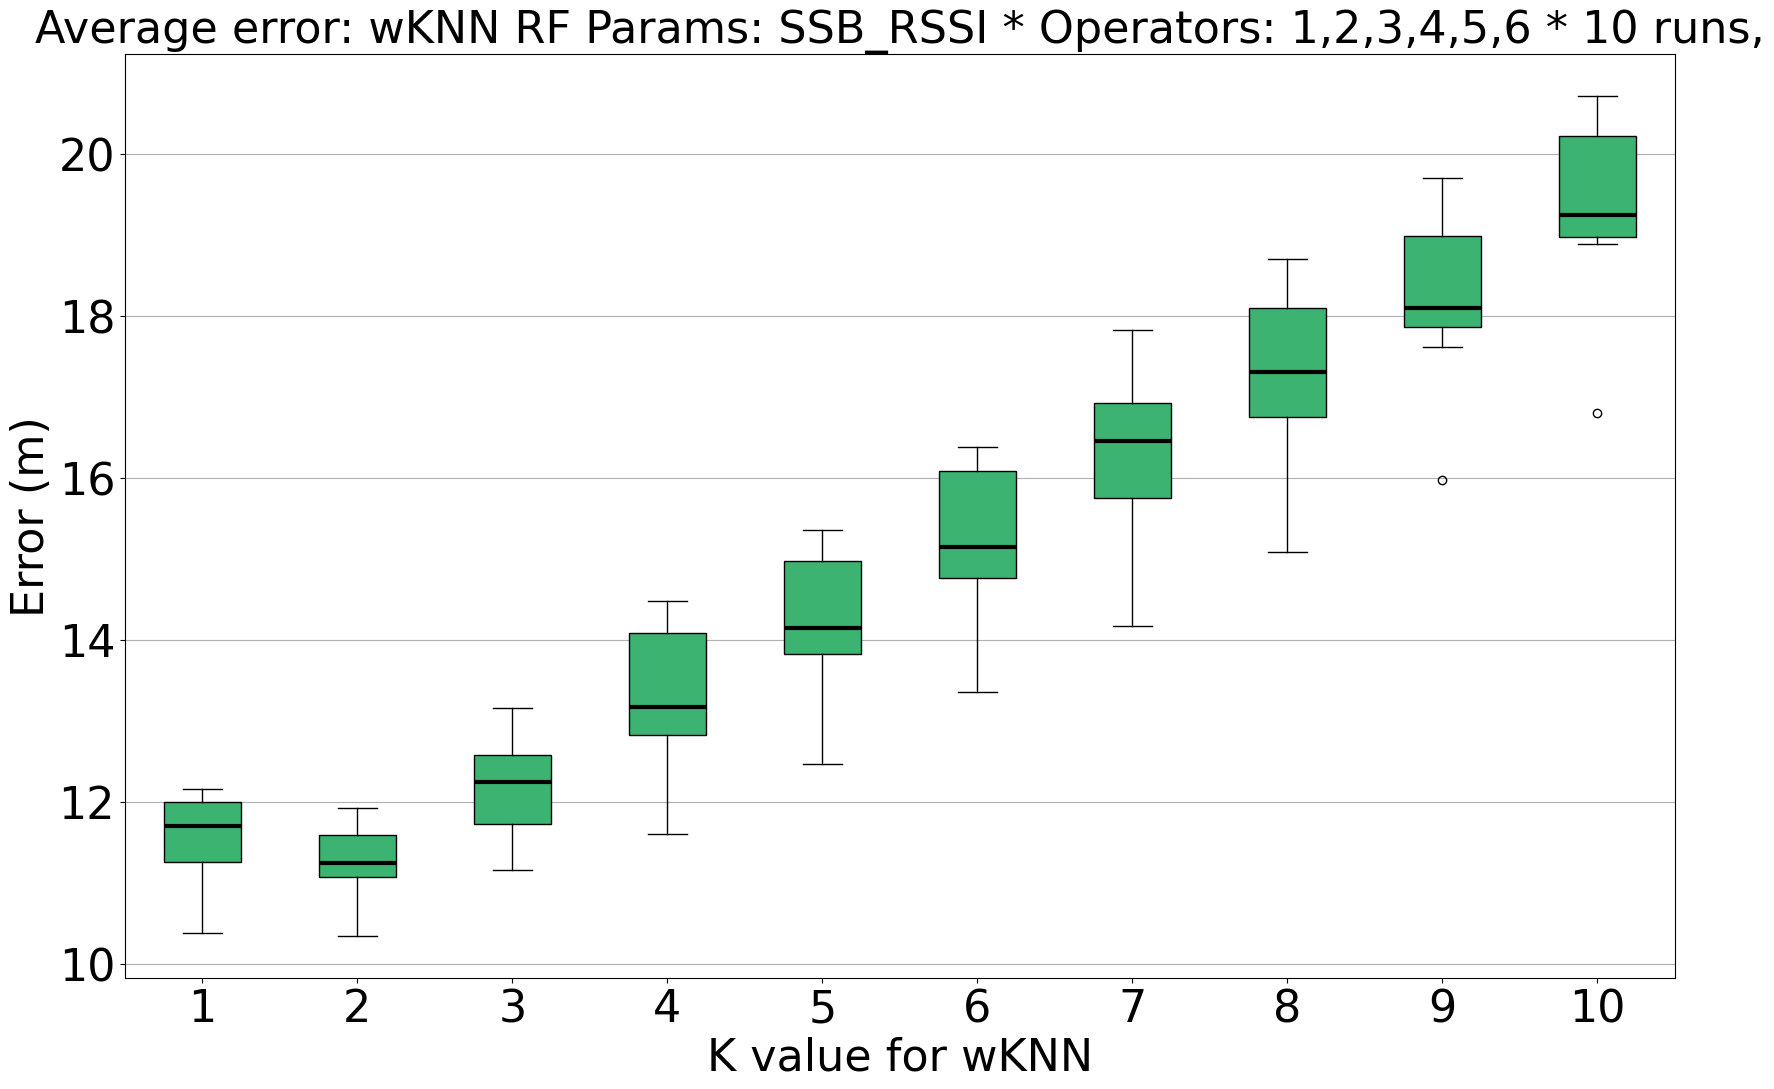

In [12]:
from scripts.utils import params_to_str
from scripts.plotting import make_boxplot

# Plotting with capped runtime data
param_str = f'RF Params: {params_to_str(rf_params)}'
operator_str = f'Operators: {operators_to_str(operator_choice)}'

title_string = f"wKNN {param_str} * {operator_str} * {n_runs} runs,"

make_boxplot(
    df=errors_df,
    title=f'Average error: {title_string}',
    x_label='K value for wKNN',
    y_label='Error (m)',
    color='mediumseagreen',
)
